Introducción a las Series de Tiempo -1

Antes de empezar
-Revisar el video de "Conceptos de Series de Tiempo"
-Obtener los archivos "AAPL_2006-01-01_to_2018-01-01.csv", "GOOGL_2006-01-01_to_2018-01-01.csv" del Centro de Descargas

In [6]:
#librerias de Base
import warnings
warnings.filterwarnings('ignore')

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot  as plt
import statsmodels.api as sm
import os

In [8]:
# carga de datos
os.chdir('C:\\Users\\ego_2\\Documents\\Ebac\\Clases\\Python\\Python_avanzado')

df_apple= pd.read_csv('Analista de datos AAPL_2006-01-01_to_2018-01-01_M30.csv', index_col='Date', parse_dates=['Date'])

df_apple.head()

,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,10.34,10.68,10.32,10.68,201853036,AAPL
2006-01-04,10.73,10.85,10.64,10.71,155225609,AAPL
2006-01-05,10.69,10.70,10.54,10.63,112396081,AAPL
2006-01-06,10.75,10.96,10.65,10.90,176139334,AAPL
2006-01-09,10.96,11.03,10.82,10.86,168861224,AAPL


Exploratory Data Analysis basico

In [9]:
df_apple.tail(5)

,Open,High,Low,Close,Volume,Name
Date,,,,,,
2017-12-22,174.68,175.42,174.50,175.01,16349444,AAPL
2017-12-26,170.80,171.47,169.68,170.57,33185536,AAPL
2017-12-27,170.10,170.78,169.71,170.60,21498213,AAPL
2017-12-28,171.00,171.85,170.48,171.08,16480187,AAPL
2017-12-29,170.52,170.59,169.22,169.23,25999922,AAPL


Analisis Univariado


In [10]:
df_apple.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3019 entries, 2006-01-03 to 2017-12-29
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    3019 non-null   float64
 1   High    3019 non-null   float64
 2   Low     3019 non-null   float64
 3   Close   3019 non-null   float64
 4   Volume  3019 non-null   int64  
 5   Name    3019 non-null   object 
dtypes: float64(4), int64(1), object(1)
memory usage: 165.1+ KB


In [11]:
#estadisticas
df_apple.describe().T

,count,mean,std,min,25%,50%,75%,max
Open,3019.0,6.467331e+01,4.452493e+01,7.39,2.342500e+01,5.786000e+01,9.916500e+01,1.751100e+02
High,3019.0,6.525683e+01,4.481177e+01,7.56,2.380500e+01,5.846000e+01,1.002750e+02,1.772000e+02
Low,3019.0,6.403344e+01,4.423083e+01,7.17,2.301500e+01,5.732000e+01,9.838500e+01,1.748600e+02
Close,3019.0,6.466289e+01,4.453645e+01,7.24,2.342000e+01,5.792000e+01,9.948000e+01,1.764200e+02
Volume,3019.0,1.311457e+08,1.018560e+08,11475922.00,5.292889e+07,1.066271e+08,1.798977e+08,8.432640e+08


In [12]:
#cambia el formato de pandas para visualizar los datos de una manera mas amigable
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [13]:
df_apple.describe().T

,count,mean,std,min,25%,50%,75%,max
Open,3019.00,64.67,44.52,7.39,23.43,57.86,99.16,175.11
High,3019.00,65.26,44.81,7.56,23.80,58.46,100.28,177.20
Low,3019.00,64.03,44.23,7.17,23.02,57.32,98.39,174.86
Close,3019.00,64.66,44.54,7.24,23.42,57.92,99.48,176.42
Volume,3019.00,131145687.66,101855966.22,11475922.00,52928887.00,106627080.00,179897651.50,843264044.00


In [14]:
#cuenta el numero de ceros por cada columna
#se aplica cuando se tienen minimo =0
df_apple[df_apple == 0].count() / df_apple.count()

Open     0.00
High     0.00
Low      0.00
Close    0.00
Volume   0.00
Name     0.00
dtype: float64

In [15]:
#estadisticas generales
df_apple.shape

(3019, 6)

Visualiszacion de series de tiempo

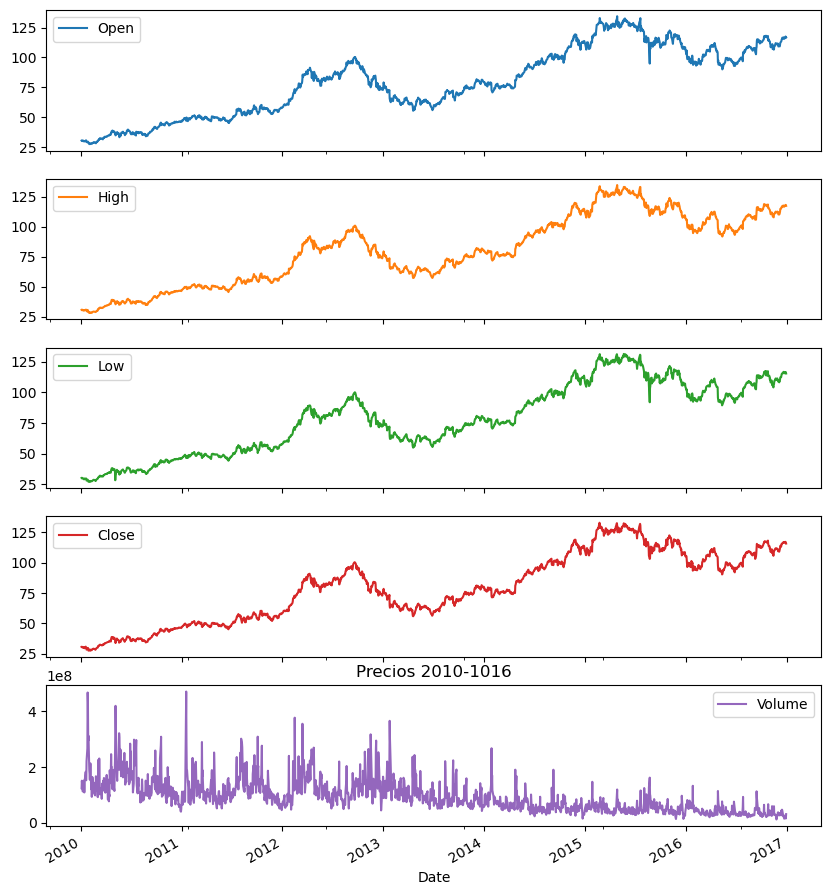

In [16]:
#visualizacion basica atraves de rangos
#usando matplotlib
df_apple['2010':'2016'].plot(subplots=True, figsize=(10,12))
plt.title('Precios 2010-1016')
plt.show()

In [17]:
#Valida cuantos stocks se estan monitoreando
df_apple['Name'].unique()

array(['AAPL'], dtype=object)

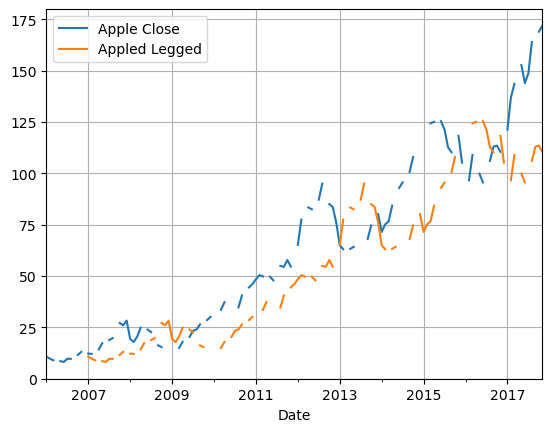

In [18]:
#visualizacion de lags
#util para ver cambios de tendencia o rupturas de la misma

#lag= 3 meses
df_apple["Close"].asfreq('M').plot(legend=True)
lag = 12
shifted=df_apple['Close'].asfreq('M').shift(lag).plot(legend=True)
shifted.legend(['Apple Close','Appled Legged'])
plt.grid()
plt.show()

In [19]:
#grafico de cambio porcentual basado en Close
df_apple['Change']=df_apple.Close.div(df_apple.Close.shift())


In [20]:
pd.set_option('display.float_format', lambda x: '%.4f' % x)
df_apple.head(10)

,Open,High,Low,Close,Volume,Name,Change
Date,,,,,,,
2006-01-03,10.3400,10.6800,10.3200,10.6800,201853036,AAPL,NaN
2006-01-04,10.7300,10.8500,10.6400,10.7100,155225609,AAPL,1.0028
2006-01-05,10.6900,10.7000,10.5400,10.6300,112396081,AAPL,0.9925
2006-01-06,10.7500,10.9600,10.6500,10.9000,176139334,AAPL,1.0254
2006-01-09,10.9600,11.0300,10.8200,10.8600,168861224,AAPL,0.9963
2006-01-10,10.8900,11.7000,10.8300,11.5500,570088246,AAPL,1.0635
2006-01-11,11.9800,12.1100,11.8000,11.9900,373548882,AAPL,1.0381
2006-01-12,12.1400,12.3400,11.9500,12.0400,320201966,AAPL,1.0042
2006-01-13,12.1400,12.2900,12.0900,12.2300,194153393,AAPL,1.0158


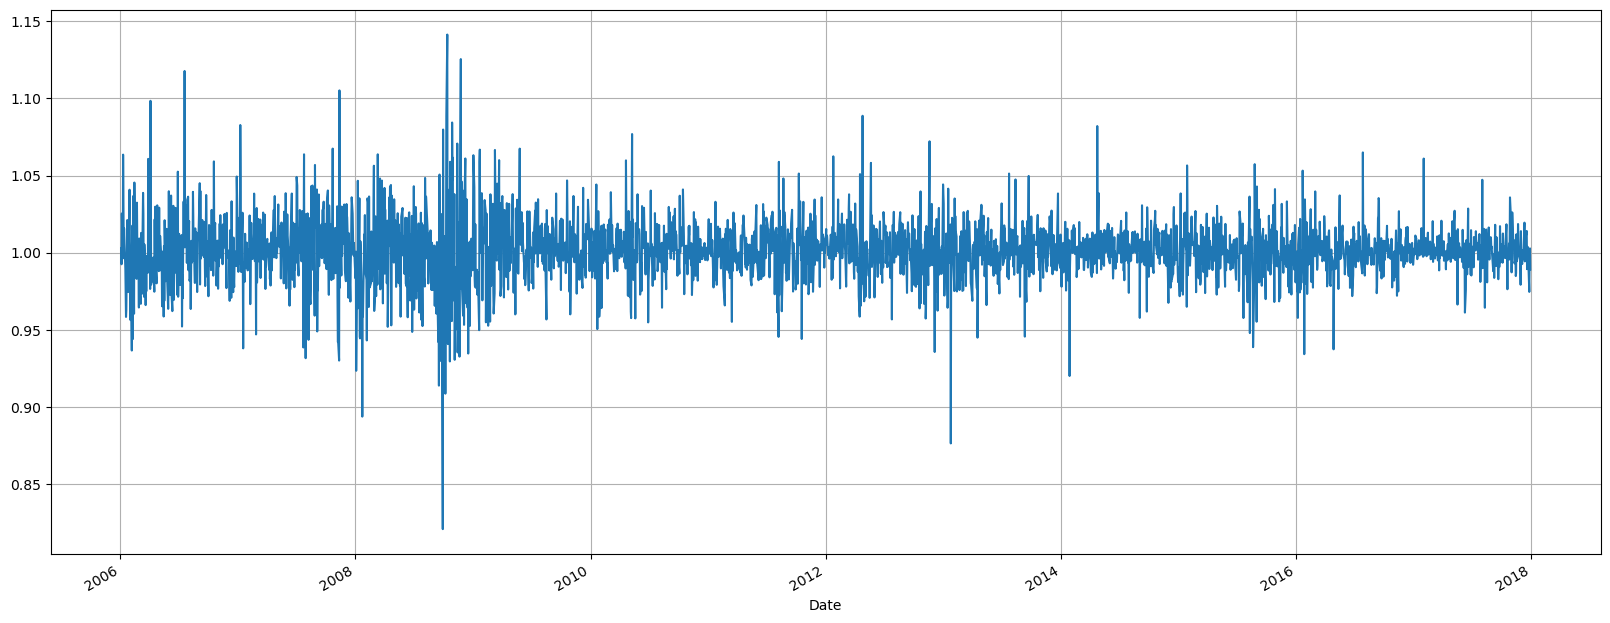

In [21]:
df_apple['Change'].plot(figsize=(20,8)).grid()

In [22]:
#calcula el retorno
df_apple['Return']=df_apple.Change.sub(1).mul(100)

In [23]:
df_apple.head(10)

,Open,High,Low,Close,Volume,Name,Change,Return
Date,,,,,,,,
2006-01-03,10.3400,10.6800,10.3200,10.6800,201853036,AAPL,NaN,NaN
2006-01-04,10.7300,10.8500,10.6400,10.7100,155225609,AAPL,1.0028,0.2809
2006-01-05,10.6900,10.7000,10.5400,10.6300,112396081,AAPL,0.9925,-0.7470
2006-01-06,10.7500,10.9600,10.6500,10.9000,176139334,AAPL,1.0254,2.5400
2006-01-09,10.9600,11.0300,10.8200,10.8600,168861224,AAPL,0.9963,-0.3670
2006-01-10,10.8900,11.7000,10.8300,11.5500,570088246,AAPL,1.0635,6.3536
2006-01-11,11.9800,12.1100,11.8000,11.9900,373548882,AAPL,1.0381,3.8095
2006-01-12,12.1400,12.3400,11.9500,12.0400,320201966,AAPL,1.0042,0.4170
2006-01-13,12.1400,12.2900,12.0900,12.2300,194153393,AAPL,1.0158,1.5781


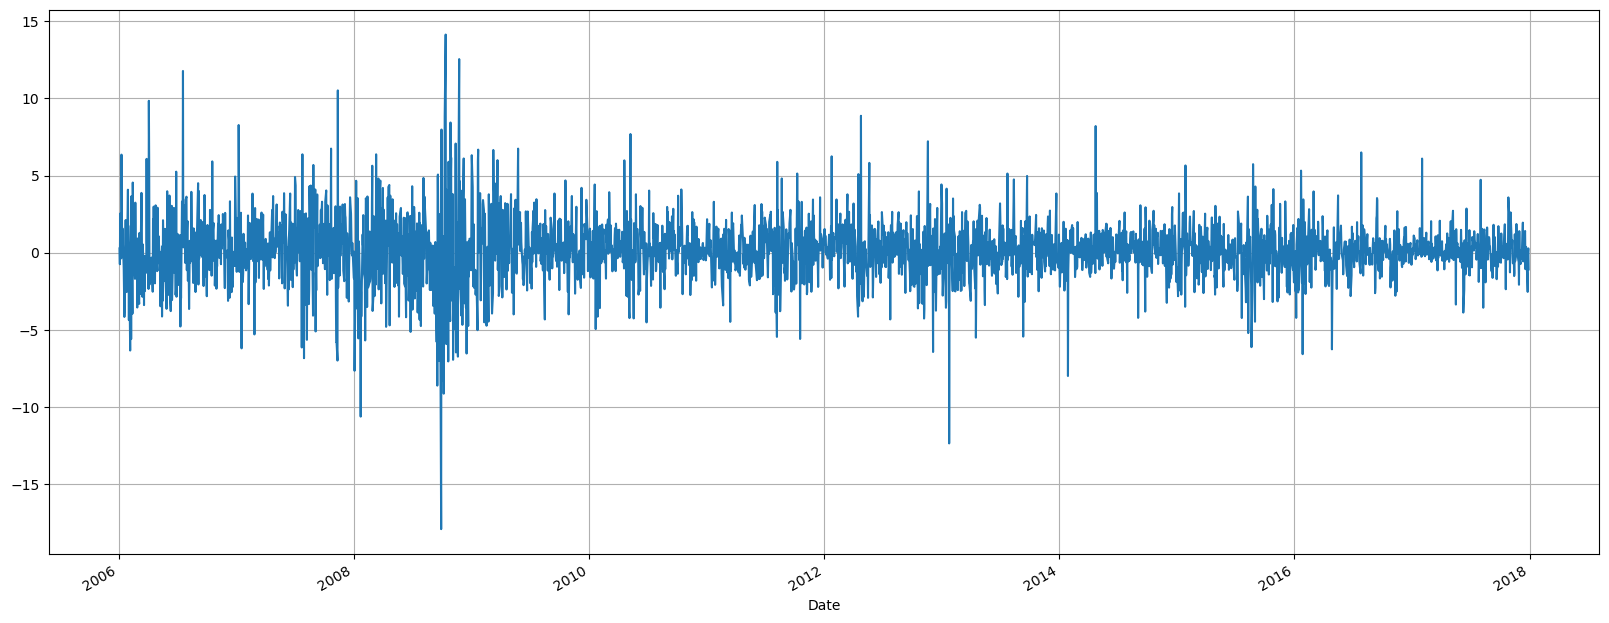

In [24]:
df_apple ['Return'].plot(figsize=(20,8)).grid()

Comparacion de dos series


In [25]:
#Se usa la función read_csv para leer el archivo.csv
#Se usa index_col con Date para usar la fecha como índice
df_google =pd.read_csv('Analista de Datos GOOGL_2006-01-01_to_2018-01-01_M31.csv', index_col='Date', parse_dates=['Date'])

In [26]:
df_google.head(10)

,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,211.4700,218.0500,209.3200,217.8300,13137450,GOOGL
2006-01-04,222.1700,224.7000,220.0900,222.8400,15292353,GOOGL
2006-01-05,223.2200,226.0000,220.9700,225.8500,10815661,GOOGL
2006-01-06,228.6600,235.4900,226.8500,233.0600,17759521,GOOGL
2006-01-09,233.4400,236.9400,230.7000,233.6800,12795837,GOOGL
2006-01-10,232.4400,235.3600,231.2500,235.1100,9104719,GOOGL
2006-01-11,235.8700,237.7900,234.8200,236.0500,9008664,GOOGL
2006-01-12,237.1000,237.7300,230.9800,232.0500,10125212,GOOGL
2006-01-13,232.3900,233.6800,231.0400,233.3600,7660220,GOOGL


In [27]:
df_apple.head(10)

,Open,High,Low,Close,Volume,Name,Change,Return
Date,,,,,,,,
2006-01-03,10.3400,10.6800,10.3200,10.6800,201853036,AAPL,NaN,NaN
2006-01-04,10.7300,10.8500,10.6400,10.7100,155225609,AAPL,1.0028,0.2809
2006-01-05,10.6900,10.7000,10.5400,10.6300,112396081,AAPL,0.9925,-0.7470
2006-01-06,10.7500,10.9600,10.6500,10.9000,176139334,AAPL,1.0254,2.5400
2006-01-09,10.9600,11.0300,10.8200,10.8600,168861224,AAPL,0.9963,-0.3670
2006-01-10,10.8900,11.7000,10.8300,11.5500,570088246,AAPL,1.0635,6.3536
2006-01-11,11.9800,12.1100,11.8000,11.9900,373548882,AAPL,1.0381,3.8095
2006-01-12,12.1400,12.3400,11.9500,12.0400,320201966,AAPL,1.0042,0.4170
2006-01-13,12.1400,12.2900,12.0900,12.2300,194153393,AAPL,1.0158,1.5781


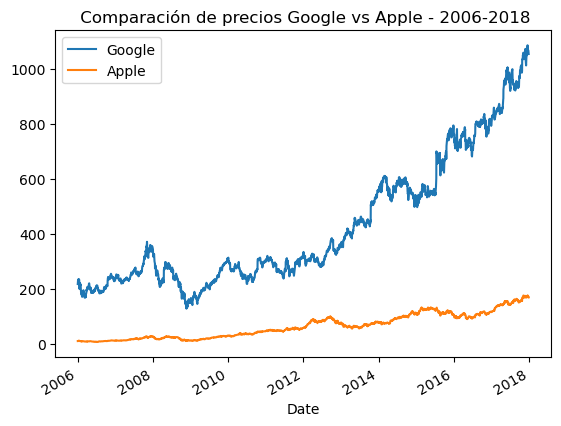

In [28]:
#Gráfico de Columnas de dos series diferentes
# Los precios son muy diferentes, lo que no deja cver el comportamiento exacto de cada una
df_google.Close.plot()
df_apple.Close.plot()
plt.legend(['Google', 'Apple'])
plt.title(' Comparación de precios Google vs Apple - 2006-2018')
plt.show()

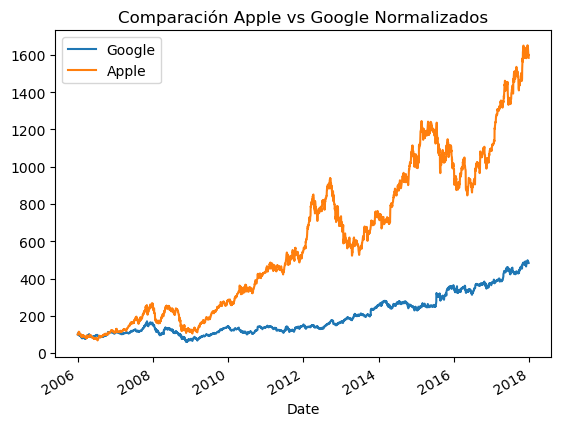

In [29]:
#Se normalizan las vistas con base 100 para tener una base de comparación similar
# La normalización toma como base el primer registro histórico (iloc[0])
#Ambos precios empiezan en 100
normal_google = df_google.Close.div(df_google.Close.iloc[0]).mul(100)
normal_apple = df_apple.Close.div(df_apple.Close.iloc[0]).mul(100)
normal_google.plot()
normal_apple.plot()
plt.legend(['Google', 'Apple'])
plt.title('Comparación Apple vs Google Normalizados')
plt.show()

Visualización de Medias

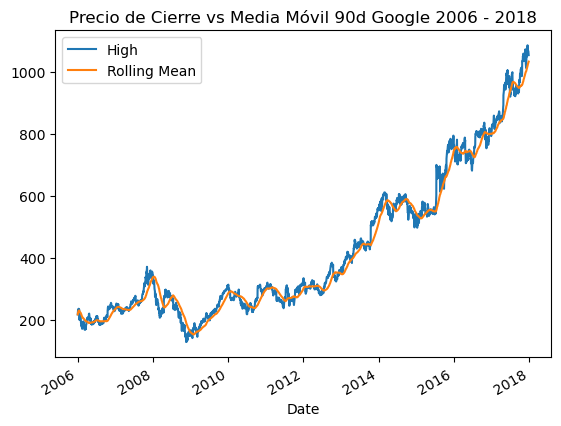

In [30]:
# Ventana Media Móvil en Google 90 días
#Se usa la función rolling
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rolling.html
rolling_google = df_google.Close.rolling('90D').mean()
df_google.Close.plot()
rolling_google.plot()
plt.title('Precio de Cierre vs Media Móvil 90d Google 2006 - 2018')
plt.legend(['High', 'Rolling Mean'])

Visualizaciones Financieras: Gráficos OHLC
Acrónimo de Open, High, Low, Close de un período de tiempo.
Se usan como una herramienta para ver cambios de precios en stocks, y otros activos financieros Son buenos para revisar el sentimiento del mercado y además hacer predicciones de cambios
El eje X, como cualquier serie de tiempo, corresponde al tiempo, mientras el eje Y al nivel de precio que se esté analizando
Se muestran el High y Low como el largo de la barra, mientras que se tienen marcas mostrando el Open y Close
El color de la barra indica si el mercado está al alza (verde) o a la baja (rojo)

In [31]:
%pip install chart_studio

#Se importan las librerías de base
%matplotlib inline
from pylab import rcParams
#Instala chart studio
from chart_studio import plotly
from chart_studio import grid_objs
import chart_studio.plotly as py
from plotly.offline import init_notebook_mode, iplot
init_notebook_mode(connected=True)
#from plotly import tools
import chart_studio.plotly as py
from plotly.offline import init_notebook_mode, iplot
init_notebook_mode(connected=True)
import plotly.graph_objs as go
import plotly.figure_factory as ff
import statsmodels.api as sm
from numpy.random import normal, seed
from scipy.stats import norm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import math
from sklearn.metrics import mean_squared_error

Note: you may need to restart the kernel to use updated packages.


In [36]:
# Gráfico OHLC
rango_ohlc = go.Ohlc(x=df_google.loc['2008-06'].index,
                     open=df_google.loc['2008-06'].Open,
                     high=df_google.loc['2008-06'].High,
                     low=df_google.loc['2008-06'].Low,
                     close=df_google.loc['2008-06'].Close)
data = [rango_ohlc]
iplot(data)

In [41]:
# Gráfico del 2008 OHLC para Google

trace= go.Ohlc(x=df_google.loc['2010'].index,
               open=df_google.loc ['2010'].Open,
               high=df_google.loc['2010'].High,
               low=df_google.loc['2010'].Low,
               close=df_google.loc ['2010'].Close)
data =[trace]
iplot(data, filename='simple_ohlc')

Gráficos de Velas - Candlesticks
Usado como una forma de visualización y apoyo de trading
Es parecido a un box plot, no se lo debe confundir
También muestra el Open, Close, High y Low con sus propios símbolos, y adaptado a la frecuencia del gráfico
Cada símbolo representa el trading en determinado tiempo (de acuerdo a la serie)
El eje X es el tiempo
Las líneas de la parte inferior y superior muestran el High y Low del período
El rectángulo muestra el rango entre el Open y el Close
Si el trading va al alza se pinta verde o blanca, mientras que si el mercado está a la baja (el Close es menor al Open), se pinta negro o rojo

In [43]:
#grafico de velas (dandlestick)
trace = go.Candlestick(x=df_google.loc['03-2008'].index,
                       open=df_google.loc['03-2008'].Open,
                       high=df_google.loc['03-2008'].High,
                       low=df_google.loc['03-2008'].Low,
                       close=df_google.loc['03-2008'].Close)
data =[trace]
iplot(data)

Descomposicion de una serie de tiempo


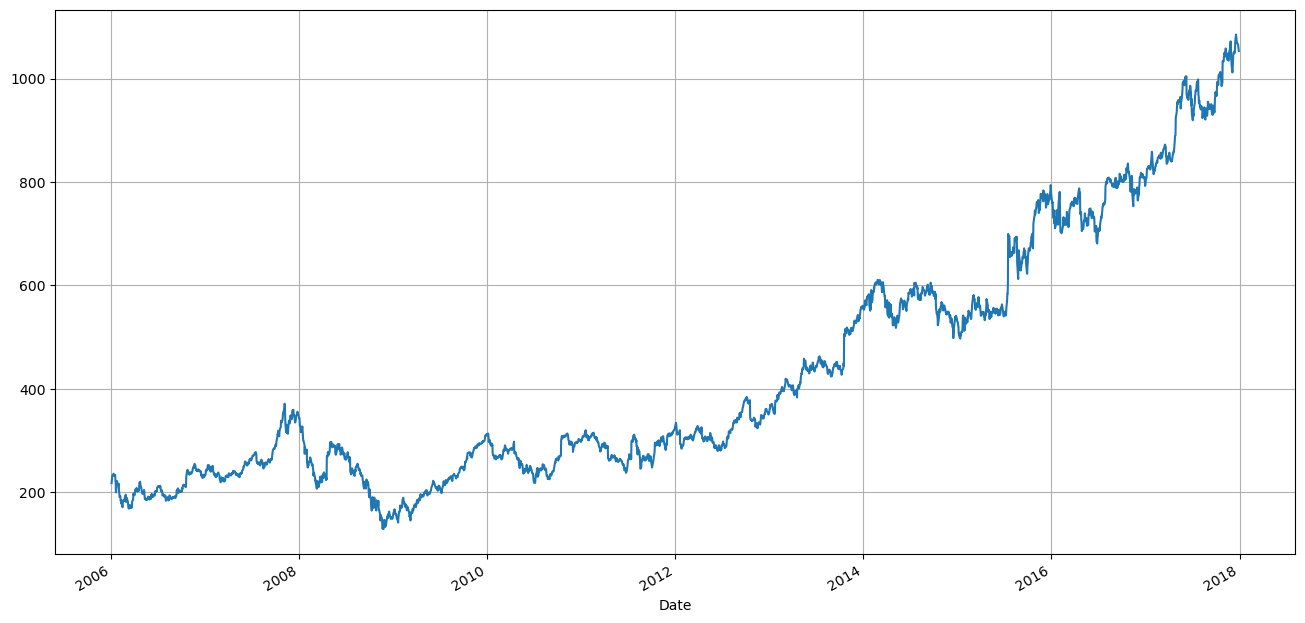

In [44]:
#se toma el precio de google
df_google['Close'].plot(figsize=(16,8)).grid()

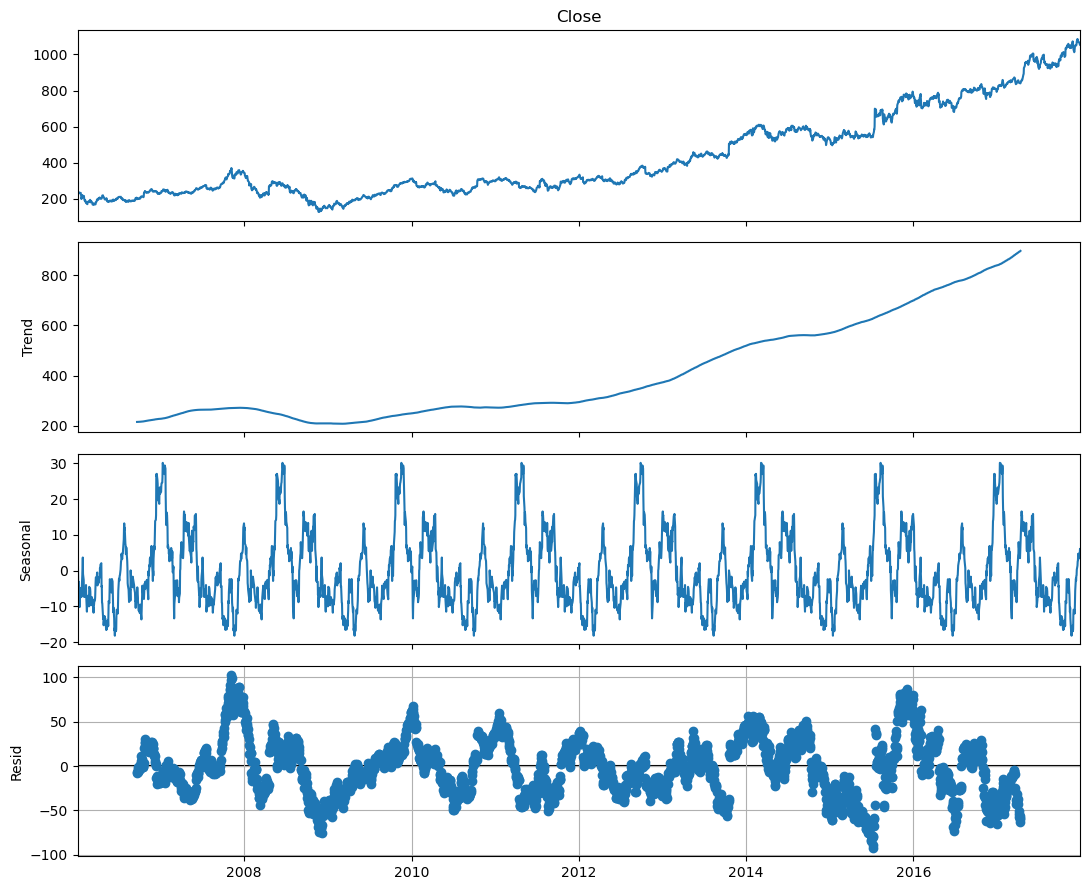

In [46]:
#Para la descomposición
rcParams['figure.figsize'] = 11, 9
#Se usa frecuencia anual
decomposed_google_volume = sm.tsa.seasonal_decompose(df_google["Close"], period=360)
figure = decomposed_google_volume.plot()
plt.grid()
plt.show()

Predicción Simple - Medias Móviles
Se hará una predicción usando medias móviles
La media móvil no es más que sacar el promedio de una ventana de tiempo hacia atrás de la variable a predecir

In [47]:
df_google.head(10)

,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,211.4700,218.0500,209.3200,217.8300,13137450,GOOGL
2006-01-04,222.1700,224.7000,220.0900,222.8400,15292353,GOOGL
2006-01-05,223.2200,226.0000,220.9700,225.8500,10815661,GOOGL
2006-01-06,228.6600,235.4900,226.8500,233.0600,17759521,GOOGL
2006-01-09,233.4400,236.9400,230.7000,233.6800,12795837,GOOGL
2006-01-10,232.4400,235.3600,231.2500,235.1100,9104719,GOOGL
2006-01-11,235.8700,237.7900,234.8200,236.0500,9008664,GOOGL
2006-01-12,237.1000,237.7300,230.9800,232.0500,10125212,GOOGL
2006-01-13,232.3900,233.6800,231.0400,233.3600,7660220,GOOGL


In [49]:
# Genera una serie con la media móvil de 60 días solo para columnas numéricas
ma_google = df_google.select_dtypes(include=[np.number]).rolling(window=60)
ma_google_mean = ma_google.mean()

In [50]:
ma_google_mean.tail(10)

,Open,High,Low,Close,Volume
Date,,,,,
2017-12-15,1017.8595,1025.8062,1011.3798,1019.1008,1586900.5000
2017-12-18,1020.0875,1028.0810,1013.5387,1021.4647,1594230.4167
2017-12-19,1022.4803,1030.5015,1016.0013,1023.8897,1584966.1500
2017-12-20,1024.8842,1032.7875,1018.2260,1026.1585,1581026.8500
2017-12-21,1027.0950,1034.6557,1020.3435,1028.0077,1563596.3667
2017-12-22,1028.9908,1036.4147,1022.2117,1029.7418,1555071.6167
2017-12-26,1030.7015,1037.9655,1023.7557,1031.2773,1536532.8667
2017-12-27,1032.2173,1039.4743,1025.3628,1032.8228,1529484.2167
2017-12-28,1033.7955,1041.0143,1026.8742,1034.2207,1527989.2333


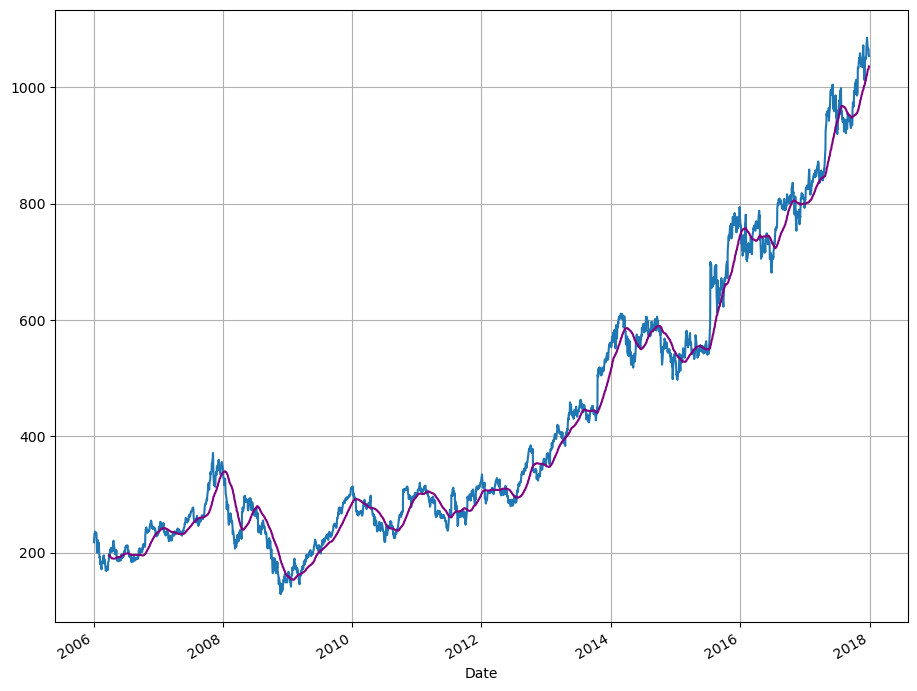

In [51]:
#se muestran los dos datasets
df_google['Close'].plot()
ma_google_mean['Close'].plot(color='purple')
plt.grid()
plt.show()

prediccion con medias moviles
- es de los modelos basicos de prediccion
- ausme que la tendencia y estacionalidad ya fueron incluidos

In [52]:
train_len = 2500
# De los días totales del dataset total, se van a tomar "train_len" como training y el resto como training
train = df_google [0: train_len] # first 2500 days as training set
test = df_google [train_len:] # the rest for testing


In [53]:
y_pred_sma = df_google.copy()
ma_window = 30
y_pred_sma ['sma_forecast'] = df_google['High'].rolling(ma_window).mean()
y_pred_sma ['sma_forecast'] [train_len] = y_pred_sma['sma_forecast'] [train_len-1]

In [54]:
y_pred_sma

,Open,High,Low,Close,Volume,Name,sma_forecast
Date,,,,,,,
2006-01-03,211.4700,218.0500,209.3200,217.8300,13137450,GOOGL,NaN
2006-01-04,222.1700,224.7000,220.0900,222.8400,15292353,GOOGL,NaN
2006-01-05,223.2200,226.0000,220.9700,225.8500,10815661,GOOGL,NaN
2006-01-06,228.6600,235.4900,226.8500,233.0600,17759521,GOOGL,NaN
2006-01-09,233.4400,236.9400,230.7000,233.6800,12795837,GOOGL,NaN
...,...,...,...,...,...,...,...
2017-12-22,1070.0000,1071.7200,1067.6400,1068.8600,889446,GOOGL,1056.9680
2017-12-26,1068.6400,1068.8600,1058.6400,1065.8500,918767,GOOGL,1057.7090
2017-12-27,1066.6000,1068.2700,1058.3800,1060.2000,1116203,GOOGL,1058.3600


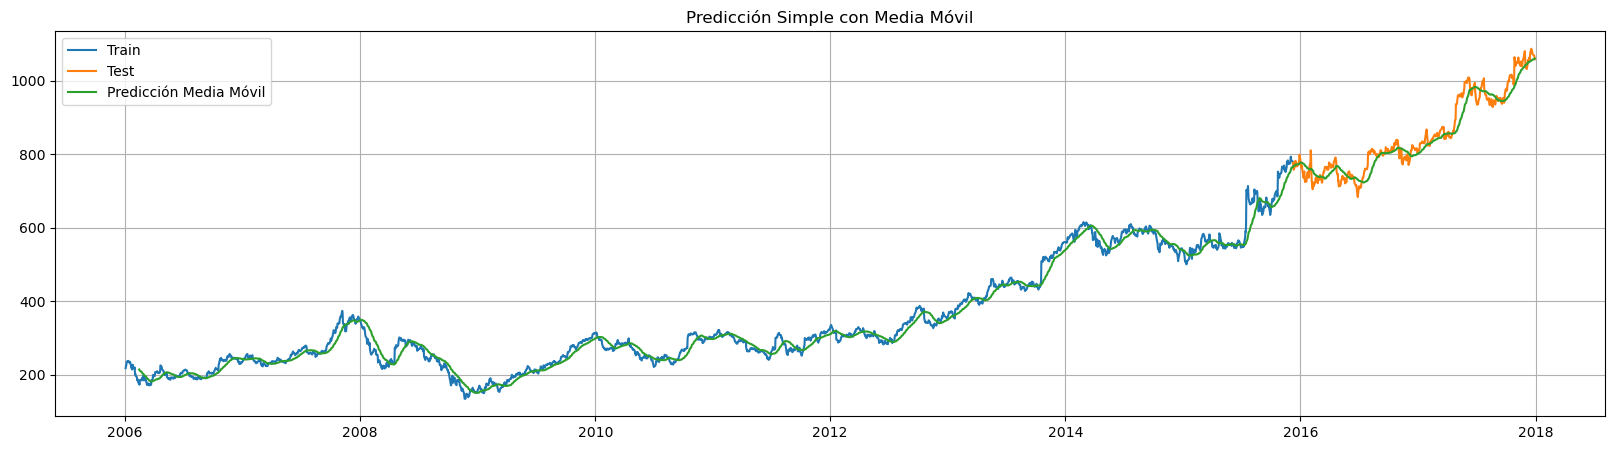

In [55]:
# Grafica las predicciones
plt.figure(figsize=(20,5))
plt.grid()
plt.plot(train ['High'], label='Train')
plt.plot(test['High'], label='Test')
plt.plot(y_pred_sma ['sma_forecast'], label='Predicción Media Móvil')
plt.legend(loc='best')
plt.title('Predicción Simple con Media Móvil')
plt.show()

In [59]:
#como saber si las predicciones fueron buenas?
#Cómo saber si las predicciones fueron buenas?
#Se usan dos medidas: RMSE (root mean square error) desviación raíz cuadrada y MAPE (mean absolute percentage error)
# RMSE muestra la raíz cuadrada de las diferencias entre los valores de predicción de un modelo y los observados
#Estas medidas nos sirven para validar qué tan buenas fueron las predicciones
# https://www.kaggle.com/code/gauravduttakiit/timeseries-forecasting-with-simple-moving-average
#MAPE: https://en.wikipedia.org/wiki/Mean_absolute_percentage_error muestra la precisión como un ratio
# RMSE: https://en.wikipedia.org/wiki/Root-mean-square_deviation

from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(test['High'], y_pred_sma['sma_forecast'] [train_len:])).round(2)
mape =np.round(np.mean(np.abs(test['High']-y_pred_sma['sma_forecast'] [train_len:])/test['High'])*100,2)
results=pd.DataFrame({'Method': ['Simple moving average forecast'], 'MAPE': [mape], 'RMSE': [rmse]}) 
results= [['Method', 'RMSE', 'MAPE']] 
results

[['Method', 'RMSE', 'MAPE']]

In [60]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(test['High'], y_pred_sma['sma_forecast'][train_len:])).round(2)
mape = np.round(np.mean(np.abs(test['High'] - y_pred_sma['sma_forecast'][train_len:]) / test['High']) * 100, 2)

results = pd.DataFrame({
    'Method': ['Simple moving average forecast'],
    'MAPE': [mape],
    'RMSE': [rmse]
})

results


,Method,MAPE,RMSE
0,Simple moving average forecast,2.4200,26.9300


In [61]:
# Compara las predicciones con la data real
y_comparison =pd.DataFrame().assign(forecast=y_pred_sma ['sma_forecast'])
y_comparison ['observed'] = df_google ['High']

In [62]:
y_comparison.tail(19)

,forecast,observed
Date,,
2017-12-04,1043.7743,1031.3400
2017-12-05,1044.8040,1036.6800
2017-12-06,1046.4813,1039.5800
2017-12-07,1048.2977,1048.9200
2017-12-08,1049.9613,1056.4200
2017-12-11,1049.7073,1056.0000
2017-12-12,1050.4630,1062.5000
2017-12-13,1050.9457,1055.4800
2017-12-14,1051.5863,1067.0800
